In [7]:
import tensorflow as tf
import tensorflow_datasets as tfds

# --- 設定 ---
DATASET_NAME = 'imagenette/320px-v2' 
BATCH_SIZE = 128
IMG_SIZE = 256

# ===================================================
# 步驟 0: GPU 檢查與配置
# ===================================================
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        # 設定 GPU 記憶體動態增長
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"成功偵測到 {len(gpus)} 個 GPU，(TF 版本: {tf.__version__})")
    except RuntimeError as e:
        print(f"GPU 設定失敗: {e}")
else:
    print("未偵測到 GPU，訓練將在 CPU 上運行。")

# ===================================================
# 步驟 1: 載入資料集
# ===================================================
print(f"--- 載入與檢查資料集：{DATASET_NAME} ---")

# tfds 會自動處理下載並存放在預設的 ~/tensorflow_datasets
(ds_train, ds_validation), ds_info = tfds.load(
    DATASET_NAME,
    split=['train', 'validation'],
    as_supervised=True,
    shuffle_files=True,
    with_info=True
)

print("資料集已就緒。")
print(f"訓練集數量: {ds_info.splits['train'].num_examples:,} | 驗證集數量: {ds_info.splits['validation'].num_examples:,}")
print(f"分類類別數: {ds_info.features['label'].num_classes}")

成功偵測到 1 個 GPU，(TF 版本: 2.10.0)
--- 載入與檢查資料集：imagenette/320px-v2 ---
資料集已就緒。
訓練集數量: 9,469 | 驗證集數量: 3,925
分類類別數: 10


--- 正在快速統計類別分布... ---


C:\Users\wtml6\AppData\Local\Temp\ipykernel_26936\2555786266.py:35: UserWarning: Glyph 39006 (\N{CJK UNIFIED IDEOGRAPH-985E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\wtml6\AppData\Local\Temp\ipykernel_26936\2555786266.py:35: UserWarning: Glyph 21029 (\N{CJK UNIFIED IDEOGRAPH-5225}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\wtml6\AppData\Local\Temp\ipykernel_26936\2555786266.py:35: UserWarning: Glyph 21517 (\N{CJK UNIFIED IDEOGRAPH-540D}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\wtml6\AppData\Local\Temp\ipykernel_26936\2555786266.py:35: UserWarning: Glyph 31281 (\N{CJK UNIFIED IDEOGRAPH-7A31}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\wtml6\AppData\Local\Temp\ipykernel_26936\2555786266.py:35: UserWarning: Glyph 22294 (\N{CJK UNIFIED IDEOGRAPH-5716}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\wtml6\AppData\Local\Temp\ipykernel_26936\2555786266.py:35: UserWarning: Glyph 29255 (\

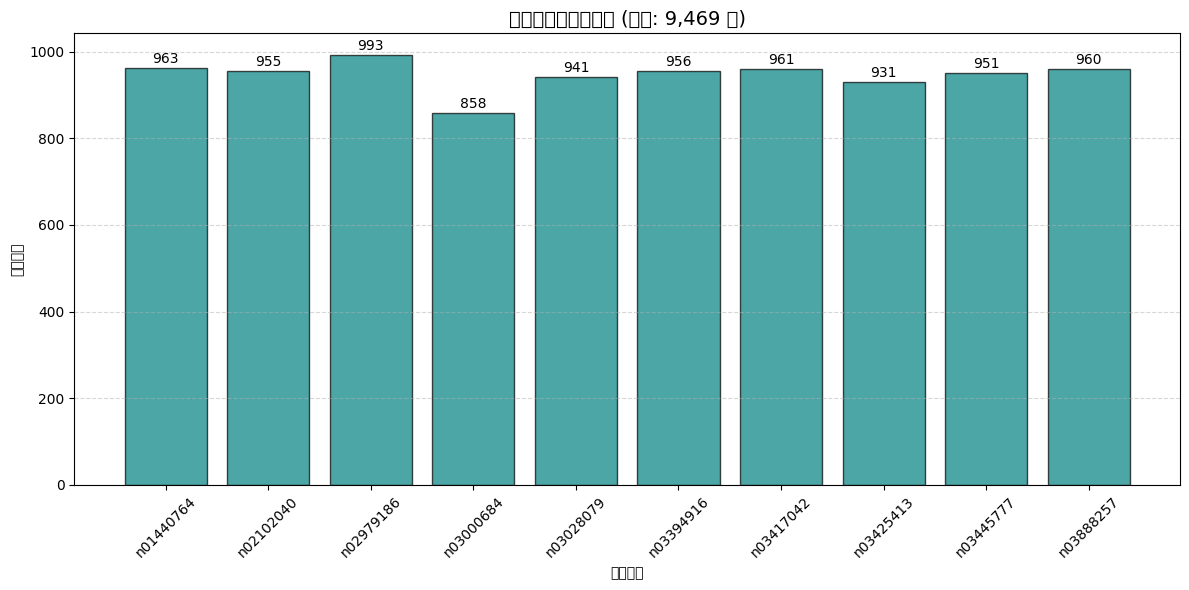


--- 隨機抽取圖片展示 ---


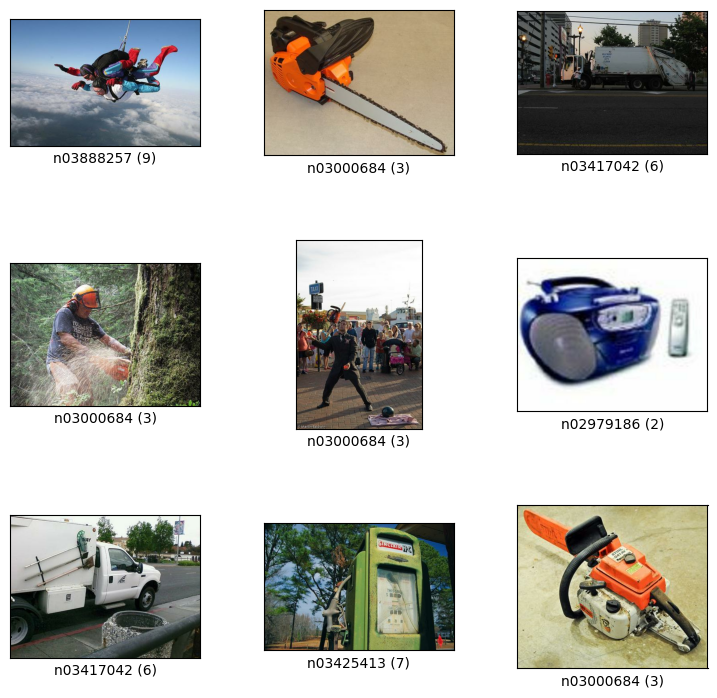


✅ 資料管線已完成最佳化設定！


In [ ]:
# ===================================================
# 2.1 定義預處理與增強函數
# ===================================================

print("--- 正在快速統計類別分布... ---")

#利用 map 只提取 label，不讀取龐大的 image 數據
labels_only_ds = ds_train_full.map(lambda img, label: label)
# 將 label 轉換成 numpy 陣列以便計算
all_labels = np.array(list(labels_only_ds.as_numpy_iterator()))

# 使用 numpy 的 bincount 計算每個類別的出現次數
counts = np.bincount(all_labels)
total_actual = counts.sum()

# 獲取 Imagenette 的類別名稱
class_names = ds_info.features['label'].names

# --- 繪製長條圖 ---
plt.figure(figsize=(12, 6))
bars = plt.bar(class_names, counts, color='teal', alpha=0.7, edgecolor='black')

# 在每個柱子上方加上具體數值
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., yval + 5, f'{int(yval)}', ha='center', va='bottom')

plt.title(f"訓練集真實類別分布 (總計: {total_actual:,} 張)", fontsize=14)
plt.xlabel("類別名稱")
plt.ylabel("圖片張數")
plt.xticks(rotation=45)  # 標籤旋轉 45 度避免擠在一起
plt.grid(axis='y', linestyle='--', alpha=0.5)

# 確保版面不會被切到
plt.tight_layout()
plt.show()
# ===================================================
# 步驟 2.2: 極速版類別統計與繪圖
# ===================================================
def normalize_img(image, label):
    # 只要 resize 就好，不除以255
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])
    return tf.cast(image, tf.float32), label

def augment(image, label):
    # 在 CPU 上進行高效增強
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_brightness(image, max_delta=0.1)
    return image, label

# ===================================================
# 步驟 2.2: 隨機抽取展示 (使用TFDS)
# ===================================================
print("\n--- 隨機抽取圖片展示 ---")
# tfds 會自動畫出圖片矩陣，並附上真實標籤
fig = tfds.show_examples(ds_train_full, ds_info)
plt.show()

# ===================================================
# 2.3 準備最終的訓練/驗證 Dataset (完美的高效管線)
# ===================================================
BUFFER_SIZE = tf.data.AUTOTUNE 

# 直接使用前面步驟 1 已經載入的 ds_train_full，不用再 load 一次
ds_train = (ds_train_full
            .map(normalize_img, num_parallel_calls=BUFFER_SIZE)
            .cache()  # 快取原始數據
            .map(augment, num_parallel_calls=BUFFER_SIZE)
            .shuffle(buffer_size=1000) 
            .batch(BATCH_SIZE)
            .prefetch(BUFFER_SIZE))

ds_validation = (ds_validation_full
                 .map(normalize_img, num_parallel_calls=BUFFER_SIZE)
                 .batch(BATCH_SIZE)
                 .prefetch(BUFFER_SIZE))

print(f"\n已完成最佳化設定！")

3.1:隨機選擇要不要翻轉
因為傳統只會讓機器死背，但這樣會讓LOSS下降很多，所以翻轉圖片，讓機器學習狗的耳朵長什麼樣，鼻子在哪...讓它更加準確

In [ ]:
# ===================================================
# 3.1 & 3.2 模型定義與編譯
# ===================================================
# 使用步驟 0 設定好的 strategy
with strategy.scope(): 
    model = tf.keras.Sequential([
        tf.keras.layers.InputLayer(input_shape=(IMG_SIZE, IMG_SIZE, 3)),
        
        tf.keras.layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        tf.keras.layers.MaxPooling2D((2, 2)),
        
        tf.keras.layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        tf.keras.layers.MaxPooling2D((2, 2)),
        
        tf.keras.layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        tf.keras.layers.GlobalAveragePooling2D(), 
        
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.Dense(num_classes, activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

print("自定義 CNN 模型已就緒。")
model.summary()

# ===================================================
# 3.3 訓練模型 (保留進度條與紀錄)
# ===================================================
EPOCHS = 15
history_logger = FullHistoryLogger()

print(f"\n--- 開始訓練 (目標: {EPOCHS} 個週期) ---")

history = model.fit(
    ds_train,
    epochs=EPOCHS,
    validation_data=ds_validation,
    verbose=2,                  
    callbacks=[history_logger]
)



print(f"\n訓練全數完成！總耗時: {(time.time() - history_logger.train_start_time)/60:.2f} 分鐘")


✅ 自定義 CNN 模型已就緒。
Model: "sequential_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_12 (Conv2D)          (None, 256, 256, 32)      896       
                                                                 
 max_pooling2d_8 (MaxPooling  (None, 128, 128, 32)     0         
 2D)                                                             
                                                                 
 conv2d_13 (Conv2D)          (None, 128, 128, 64)      18496     
                                                                 
 max_pooling2d_9 (MaxPooling  (None, 64, 64, 64)       0         
 2D)                                                             
                                                                 
 conv2d_14 (Conv2D)          (None, 64, 64, 128)       73856     
                                                                 
 global_average_pooling2d_4   (None, 


--- 訓練結果分析 ---
最低驗證損失 (Min Validation Loss): 1.0130
模型達到最低驗證損失的 最佳時間 (Best Epoch) 是第 14 週期。


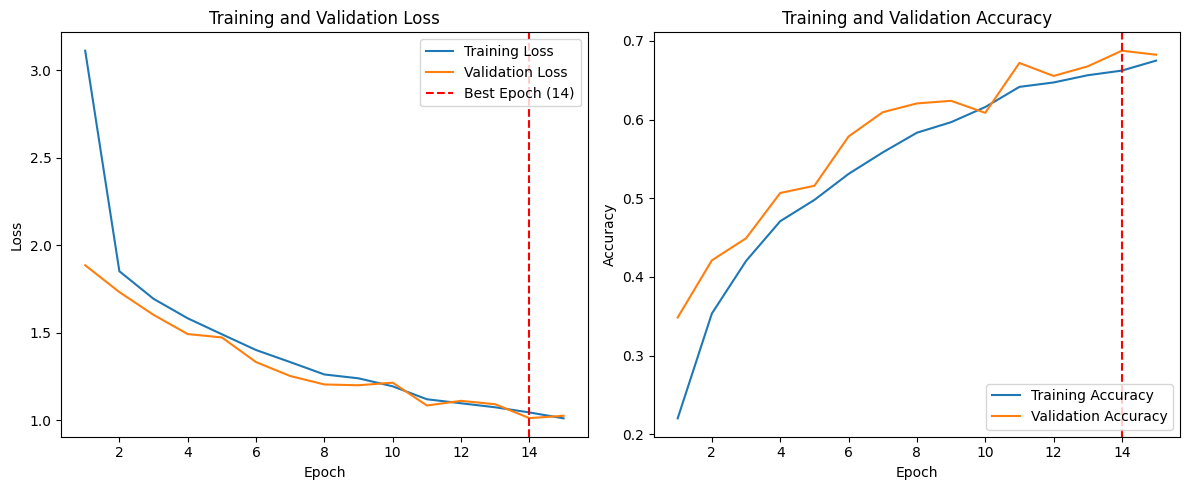

已生成圖表：training_history_imagenette.png


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# ===================================================
# 4.1 找出最佳時間
# ===================================================
val_loss = history.history['val_loss']
min_val_loss = min(val_loss)
best_epoch = np.argmin(val_loss) + 1 # 週期從 1 開始

print(f"\n--- 訓練結果分析 ---")
print(f"最低驗證損失 (Min Validation Loss): {min_val_loss:.4f}")
print(f"模型達到最低驗證損失的 最佳時間 (Best Epoch) 是第 {best_epoch} 週期。")

# ===================================================
# 4.2 繪製 Accuracy 和 Loss 曲線圖
# ===================================================
def plot_history(history, filename='training_history_imagenette.png'):
    """繪製訓練過程中的 Accuracy 和 Loss 曲線圖。"""
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    
    #讓 X 軸從 1 開始算 (1 到 epochs)
    epochs_range = range(1, len(acc) + 1)

    plt.figure(figsize=(12, 5))

    # 繪製 Loss 曲線
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')
    # 微調：X 軸校正後，垂直線直接畫在 best_epoch 即可
    plt.axvline(x=best_epoch, color='r', linestyle='--', label=f'Best Epoch ({best_epoch})')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend(loc='upper right')

    # 繪製 Accuracy 曲線
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.axvline(x=best_epoch, color='r', linestyle='--')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend(loc='lower right')
    
    plt.tight_layout()
    plt.savefig(filename)
    plt.show()

plot_history(history)
print(f"已生成圖表：training_history_imagenette.png")